# Notebook for X-Ray Light curve model Project

In [1]:
from plot_results import *
from chandra_phase_analysis import *
from compute_flux_vs_nH import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## Single ObsID 15803 LC fitting

### Soft Band (0.5 - 2.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/soft/single
Removed 131 zero/NaN flux data points (1367 remaining)


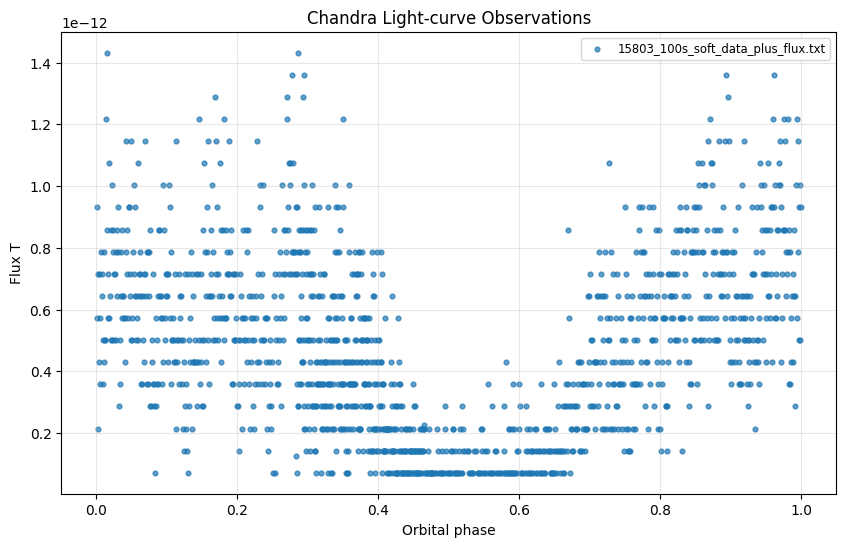

In [2]:
# Plot soft band LC
obs_column = "flux_t"
time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC_CIAO/soft/single", obs_column = obs_column, time_column = time_column)
n_before = len(df)
df = df[(df['rate'] != 0) & (df['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(df)} remaining)")
plot_phase(df, None, obs_column_name = obs_column)

In [3]:
# Generate Model LC
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_soft.csv \
--output ./analyses/sim_flux_interpolate_tbabs_15803_soft.csv \
--i0 20.0 --lam 0.533551 --lam2 0.533551 --r 0.01 --R 2.0 --converge-rmax")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.01 solar radii
  R (companion radius): 2.0 solar radii
  d1 (emitter separation): 11.0 solar radii
  d2 (companion separation): 8.0 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 20.0 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 38.0
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_soft.csv
  flux_type: erg
  lam: 0.533551
  lam2: 0.533551
  Output file: ./analyses/sim_flux_interpolate_tbabs_15803_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_interpolate_tbabs_15803_soft.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


0


Fitting column: nfl_soft_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 1.914

Fitting column: nfl_soft_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 1.483


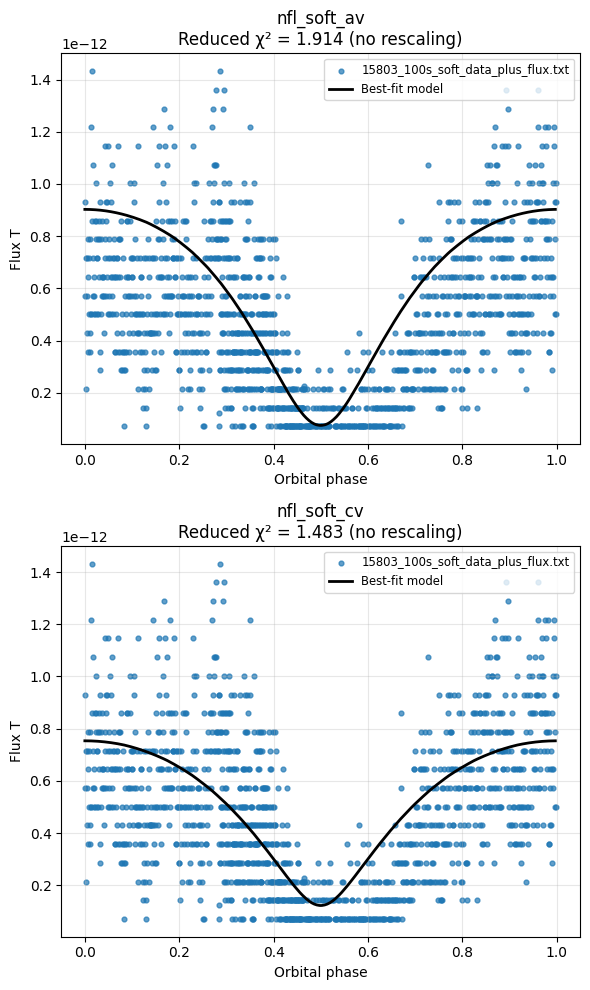

In [4]:
# Fit model to data
sim_df = pd.read_csv("./analyses/sim_flux_interpolate_tbabs_15803_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=False)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=False)

### Broad Band (0.5 - 7.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/broad/single
Removed 56 zero/NaN flux data points (1442 remaining)


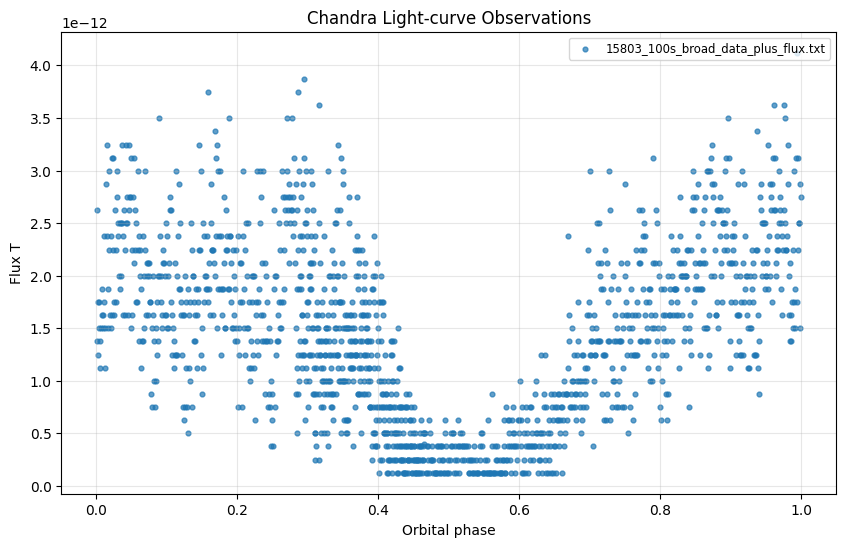

In [5]:
# Plot LC of 15803
obs_column = "flux_t"
time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC_CIAO/broad/single", obs_column = obs_column, time_column = time_column)
n_before = len(df)
df = df[(df['rate'] != 0) & (df['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(df)} remaining)")
plot_phase(df, None, obs_column_name = obs_column)

In [6]:
# Generate Model LC
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_broad.csv \
--output ./analyses/sim_flux_interpolate_tbabs_15803_broad.csv \
--i0 20.0 --lam 0.533551 --lam2 0.533551 --r 0.01 --R 2.0 --converge-rmax")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.01 solar radii
  R (companion radius): 2.0 solar radii
  d1 (emitter separation): 11.0 solar radii
  d2 (companion separation): 8.0 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 20.0 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 38.0
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_broad.csv
  flux_type: erg
  lam: 0.533551
  lam2: 0.533551
  Output file: ./analyses/sim_flux_interpolate_tbabs_15803_broad.csv

Detected energy bands in CSV: broad

Simulation completed! Results saved to ./analyses/sim_flux_interpolate_tbabs_15803_broad.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


0


Fitting column: nfl_broad_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 4.334

Fitting column: nfl_broad_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 4.696


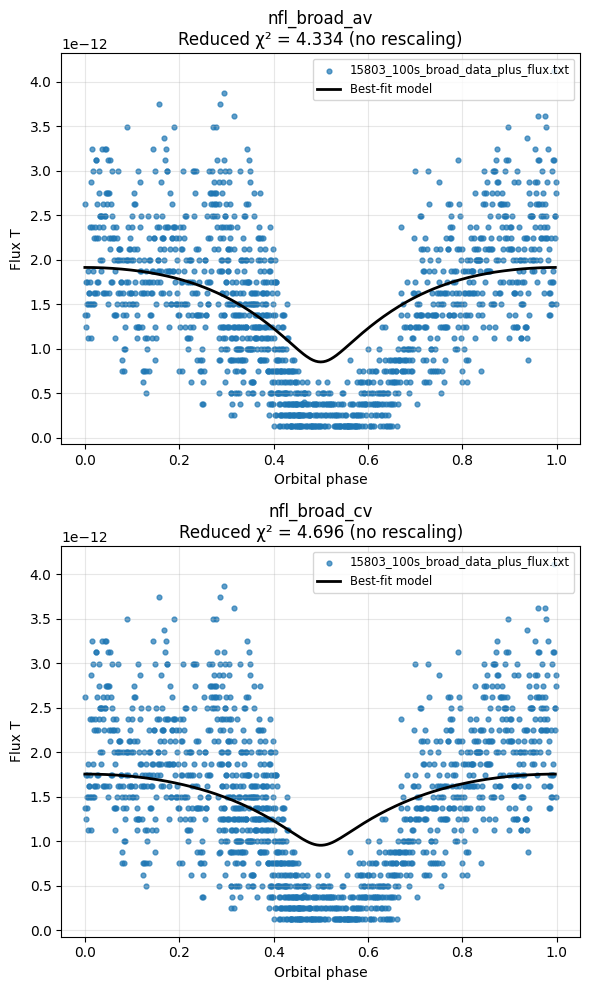

In [7]:
# Fit model to data
sim_df = pd.read_csv("./analyses/sim_flux_interpolate_tbabs_15803_broad.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=False)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=False)